In [1]:
import pandas as pd 
import numpy as np 
import seaborn as sns
import matplotlib.pyplot  as plt 
from sklearn.model_selection import train_test_split 
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

In [2]:
data = pd.read_csv("Salary_Data.csv")

In [3]:
data.head()

,YearsExperience,Salary
0,1.1,39343.0
1,1.3,46205.0
2,1.5,37731.0
3,2.0,43525.0
4,2.2,39891.0


In [86]:
x = data.iloc[:,:-1]
y= data.iloc[:,1]
x_train, x_test, y_train, y_test =train_test_split(x,y, train_size=0.7, random_state=10)

In [87]:
from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(degree=30)
x_poly_train =poly.fit_transform(x_train) 
x_poly_test = poly.transform(x_test)


In [88]:
poly_model = LinearRegression()
poly_model.fit(x_poly_train, y_train)
y_poly_pred_train = poly_model.predict(x_poly_train)
y_poly_pred_test = poly_model.predict(x_poly_test)

In [89]:
x_range = np.linspace(x.min(),x.max() , 100).reshape(-1,1)
x_range_poly = poly.transform(x_range)
y_range_pred = poly_model.predict(x_range_poly)

/home/sagagen/Desktop/SagaGen/sagaTeach/.env/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


In [90]:
lin_reg = LinearRegression()
lin_reg.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


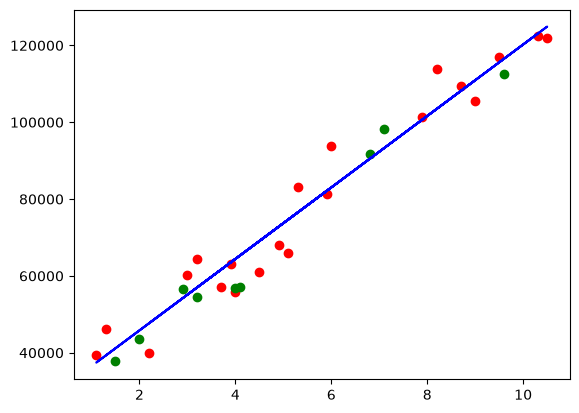

In [91]:
plt.scatter(x_train, y_train, color ="red")
plt.scatter(x_test, y_test, color = "green", label="Test Data")
plt.plot(x_train, lin_reg.predict(x_train), color ="blue")

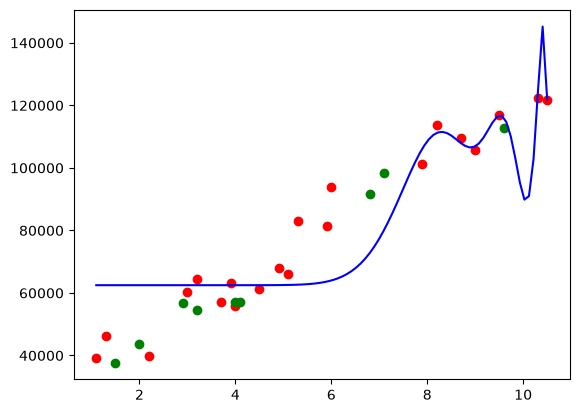

In [92]:
plt.scatter(x_train, y_train, color ="red")
plt.scatter(x_test, y_test, color = "green", label="Test Data")
plt.plot(x_range, y_range_pred, color ="blue",label = "poly Regression")

In [93]:
y_lin_pred_train = lin_reg.predict(x_train)
y_lin_pred_test = lin_reg.predict(x_test)
train_lin_r2 = r2_score(y_train, y_lin_pred_train)
test_lin_r2 = r2_score(y_test, y_lin_pred_test)
print(train_lin_r2)
print(test_lin_r2)

0.9505319424191246
0.9647278344670828


In [94]:
# y_poly_pred_train = poly_model.predict(x_train)
# y_poly_pred_test = poly_model.predict(x_test)
train_lin_r2 = r2_score(y_train, y_poly_pred_train)
test_lin_r2 = r2_score(y_test, y_poly_pred_test)
print("r2score _train",train_lin_r2)
print("r2score _test",test_lin_r2)

r2score _train 0.7980810987776853
r2score _test 0.6694519202351268
